In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

In [2]:
os.listdir('car parts/train')

['AIR COMPRESSOR',
 'ALTERNATOR',
 'BATTERY',
 'BRAKE CALIPER',
 'BRAKE PAD',
 'BRAKE ROTOR',
 'CAMSHAFT',
 'CARBERATOR',
 'COIL SPRING',
 'CRANKSHAFT',
 'CYLINDER HEAD',
 'DISTRIBUTOR',
 'ENGINE BLOCK',
 'FUEL INJECTOR',
 'FUSE BOX',
 'GAS CAP',
 'HEADLIGHTS',
 'IDLER ARM',
 'IGNITION COIL',
 'LEAF SPRING',
 'LOWER CONTROL ARM',
 'MUFFLER',
 'OIL FILTER',
 'OIL PAN',
 'OVERFLOW TANK',
 'OXYGEN SENSOR',
 'PISTON',
 'RADIATOR',
 'RADIATOR FAN',
 'RADIATOR HOSE',
 'RIM',
 'SPARK PLUG',
 'STARTER',
 'TAILLIGHTS',
 'THERMOSTAT',
 'TORQUE CONVERTER',
 'TRANSMISSION',
 'VACUUM BRAKE BOOSTER',
 'VALVE LIFTER',
 'WATER PUMP']

In [3]:
image = cv2.imread('car parts/train/AIR COMPRESSOR/034.jpg')
image.shape

(224, 224, 3)

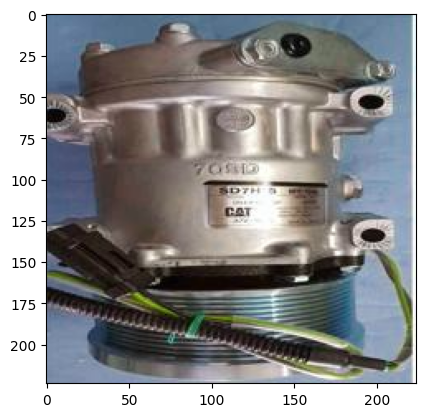

In [4]:
plt.imshow(image)

In [5]:
labels = {
    'AIR COMPRESSOR': 0,
    'ALTERNATOR': 1,
    'BATTERY': 2,
    'BRAKE CALIPER': 3,
    'BRAKE PAD': 4,
    'BRAKE ROTOR': 5,
    'CAMSHAFT': 6,
    'CARBERATOR': 7,
    'COIL SPRING': 8,
    'CRANKSHAFT': 9,
    'CYLINDER HEAD': 10,
    'DISTRIBUTOR': 11,
    'ENGINE BLOCK': 12,
    'FUEL INJECTOR': 13,
    'FUSE BOX': 14,
    'GAS CAP': 15,
    'HEADLIGHTS': 16,
    'IDLER ARM': 17,
    'IGNITION COIL': 18,
    'LEAF SPRING': 19,
    'LOWER CONTROL ARM': 20,
    'MUFFLER': 21,
    'OIL FILTER': 22,
    'OIL PAN': 23,
    'OVERFLOW TANK': 24,
    'OXYGEN SENSOR': 25,
    'PISTON': 26,
    'RADIATOR': 27,
    'RADIATOR FAN': 28,
    'RADIATOR HOSE': 29,
    'RIM': 30,
    'SPARK PLUG': 31,
    'STARTER': 32,
    'TAILLIGHTS': 33,
    'THERMOSTAT': 34,
    'TORQUE CONVERTER': 35,
    'TRANSMISSION': 36,
    'VACUUM BRAKE BOOSTER': 37,
    'VALVE LIFTER': 38,
    'WATER PUMP': 39
}

In [6]:
from tensorflow.keras.applications.efficientnet import preprocess_input

X_train = []
y_train = []

for i in os.listdir('car parts/train/'):
    for j in os.listdir(f'car parts/train/{i}'):
        img = cv2.imread(f'car parts/train/{i}/{j}')
        img = cv2.resize(img, (220, 220))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = preprocess_input(img)
        X_train.append(img)
        y_train.append(labels[i])

X_train = np.array(X_train)
y_train = np.array(y_train)

In [7]:
X_train.shape

(6917, 220, 220, 3)

In [8]:
y_train.shape

(6917,)

In [9]:
X_test = []
y_test = []

for i in os.listdir('car parts/test/'):
    for j in os.listdir(f'car parts/test/{i}'):
        img = cv2.imread(f'car parts/test/{i}/{j}')
        img = cv2.resize(img, (220, 220))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = preprocess_input(img)
        X_test.append(img)
        y_test.append(labels[i])

X_test = np.array(X_test)
y_test = np.array(y_test)

In [10]:
X_test.shape

(200, 220, 220, 3)

In [11]:
y_test.shape

(200,)

In [12]:
X_valid = []
y_valid = []

for i in os.listdir('car parts/valid/'):
    for j in os.listdir(f'car parts/valid/{i}'):
        img = cv2.imread(f'car parts/valid/{i}/{j}')
        img = cv2.resize(img, (220, 220))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = preprocess_input(img)
        X_valid.append(img)
        y_valid.append(labels[i])

X_valid = np.array(X_valid)
y_valid = np.array(y_valid)

In [13]:
X_valid.shape

(200, 220, 220, 3)

In [14]:
y_valid.shape

(200,)

In [15]:
from sklearn.utils import shuffle

In [16]:
X_train, y_train = shuffle(X_train, y_train, random_state=42)
X_test, y_test = shuffle(X_test, y_test, random_state=42)
X_valid, y_valid = shuffle(X_valid, y_valid, random_state=42)

In [17]:
from keras.utils import to_categorical

In [18]:
y_train = to_categorical(y_train, num_classes=len(os.listdir('car parts/train/')))
y_test = to_categorical(y_test, num_classes=len(os.listdir('car parts/test/')))
y_valid = to_categorical(y_valid, num_classes=len(os.listdir('car parts/valid/')))

In [19]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(220, 220, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
output = Dense(40, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    epochs=15,
    batch_size=32
)

Epoch 1/15
217/217 ━━━━━━━━━━━━━━━━━━━━ 42s 176ms/step - accuracy: 0.6457 - loss: 1.4556 - val_accuracy: 0.8950 - val_loss: 0.5462
Epoch 2/15
217/217 ━━━━━━━━━━━━━━━━━━━━ 40s 185ms/step - accuracy: 0.8736 - loss: 0.5290 - val_accuracy: 0.9150 - val_loss: 0.3728
Epoch 3/15
217/217 ━━━━━━━━━━━━━━━━━━━━ 39s 181ms/step - accuracy: 0.9046 - loss: 0.3788 - val_accuracy: 0.9300 - val_loss: 0.3138
Epoch 4/15
217/217 ━━━━━━━━━━━━━━━━━━━━ 39s 180ms/step - accuracy: 0.9267 - loss: 0.3017 - val_accuracy: 0.9300 - val_loss: 0.2917
Epoch 5/15
217/217 ━━━━━━━━━━━━━━━━━━━━ 40s 183ms/step - accuracy: 0.9316 - loss: 0.2581 - val_accuracy: 0.9350 - val_loss: 0.2622
Epoch 6/15
217/217 ━━━━━━━━━━━━━━━━━━━━ 39s 181ms/step - accuracy: 0.9403 - loss: 0.2242 - val_accuracy: 0.9400 - val_loss: 0.2378
Epoch 7/15
217/217 ━━━━━━━━━━━━━━━━━━━━ 38s 177ms/step - accuracy: 0.9506 - loss: 0.1966 - val_accuracy: 0.9400 - val_loss: 0.2405
Epoch 8/15
217/217 ━━━━━━━━━━━━━━━━━━━━ 39s 181ms/step - accuracy: 0.9543 - loss: 0

In [20]:
base_model.trainable = True

model.compile(
    optimizer=Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    epochs=10
)

Epoch 1/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 249s 1s/step - accuracy: 0.6587 - loss: 1.2386 - val_accuracy: 0.8850 - val_loss: 0.4631
Epoch 2/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 227s 1s/step - accuracy: 0.7596 - loss: 0.8550 - val_accuracy: 0.8850 - val_loss: 0.4530
Epoch 3/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 221s 1s/step - accuracy: 0.8184 - loss: 0.6459 - val_accuracy: 0.8950 - val_loss: 0.3929
Epoch 4/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 220s 1s/step - accuracy: 0.8492 - loss: 0.5300 - val_accuracy: 0.9100 - val_loss: 0.3518
Epoch 5/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 221s 1s/step - accuracy: 0.8723 - loss: 0.4347 - val_accuracy: 0.9100 - val_loss: 0.3174
Epoch 6/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 221s 1s/step - accuracy: 0.8997 - loss: 0.3679 - val_accuracy: 0.9150 - val_loss: 0.2939
Epoch 7/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 221s 1s/step - accuracy: 0.9099 - loss: 0.3197 - val_accuracy: 0.9150 - val_loss: 0.2781
Epoch 8/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 221s 1s/step - accuracy: 0.9157 - loss: 0.2901 - val_accu

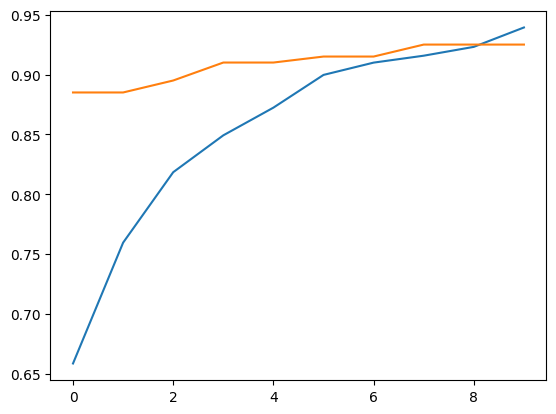

In [21]:
plt.plot(history_fine.history['accuracy'])
plt.plot(history_fine.history['val_accuracy'])

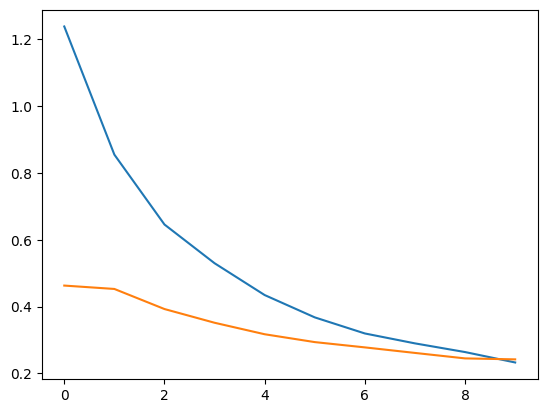

In [22]:
plt.plot(history_fine.history['loss'])
plt.plot(history_fine.history['val_loss'])

In [23]:
img = cv2.imread('BrakePad.jpg')
img = cv2.resize(img, (220, 220))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = img.reshape(1, 220, 220, 3)

pred = model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 838ms/step


In [24]:
print(np.argmax(pred))

4


In [25]:
img = cv2.imread('Radiator_fan.png')
img = cv2.resize(img, (220, 220))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = img.reshape(1, 220, 220, 3)

pred = model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


In [26]:
print(np.argmax(pred))

28


In [27]:
img = cv2.imread('Ignition_coil.jpg')
img = cv2.resize(img, (220, 220))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = img.reshape(1, 220, 220, 3)

pred = model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


In [28]:
print(np.argmax(pred))

18
